# RUN.PROJ.101 Galaxy Morphology with Visit Images

For the Rubin Undergraduate Network. <br>
Data Release: <a href="https://dp1.lsst.io/">Data Preview 1</a> <br>

**Learning objective:** To learn how to use `statmorph` in conjunction with `visit_images` to calculate nonparametric galaxy morphology.

**LSST data products:** `visit_images`

**Packages:** `lsst.daf.butler`, `lsst.rsp`, `lsst.afw.display`, `photutils.segmentation`, `statmorph`

**Credit:**
Based on Rubin DP1 Tutorial notebooks created by the community science team. Resources assembled by the Rubin Undergraduate Network. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Please contact jacob.yuzovitskiy@macaulay.cuny.edu with questions, comments, or corrections.

## 1. Introduction

Nonparametric galaxy morphology is the study of the shape of distant galaxies. Precicely quantifying the light distribution in a galaxy can help scientists understand what it was doing in the past, and what it might do in the future. `Statmorph` is a relatively simple python package takes an input of an `image`, `segment map`, and `weightmap` to generate a `Source_Morphology` object, which contains useful information about the morphology of an object. In this project/wrapper, we will use the Rubin Observatory's tutorial "202_2_Visit_images" to pull an image of a galaxy from the Rubin Data Preview 1 (DP1), get its segment map, generate a weight map, and run it through statmorph to get a `Source_Morphology` object for that galaxy.

## 2. Getting a Visit Image from DP1

To begin, we need an image of a galaxy to process through `statmorph`. To get this, we follow &sect;1 - &sect;2.2 of the Rubin DP1 tutorial "202_2_Visit_images," available in the /notebooks/ folder. We will be using the Butler image service to write a "query" that can retrieve Rubin images.

In [1]:
#Importing necessary packages
from lsst.daf.butler import Butler, Timespan
from lsst.rsp import get_tap_service
import lsst.geom
import lsst.afw.display as afwDisplay
from astropy.time import Time
import numpy as np

In [96]:
#Initiating the Butler
butler = Butler("dp1", collections="LSSTComCam/DP1")
assert butler is not None

#Telling our Butler we're interested in visit images
butler.get_dataset_type('visit_image')

DatasetType('visit_image', {band, instrument, day_obs, detector, physical_filter, visit}, ExposureF)

At this point, the image 'Butler' is ready for duty. It is now time to specify the Right Ascension (RA) and Declination (DEC) of our target galaxy. These are the specific coordinates that give the location of our galaxy in space, and we will use the coordinates of a galaxy in the Extended Chandra Deep Field South (ECDFS), one of the 7 survey areas in the Rubin DP1.

In [97]:
ra = 52.892299
dec = -27.833123

We will now write our "query" — this is a set of instructions to the image Butler that tell it which picture it should retrieve from the vast Rubin database. `band` represents one of six filters on the LSST camera, in this case the 'r' band. `time1` and `time2` are the start and end of our observing `timespan`. Any images taken outside of this timespan will not be included in the result of our query. Try to interpret the language of our call to the `butler.query_datasets()` function — try to see where all the components of our request come in.

In [98]:
band = "r"
time1 = Time("2024-11-09T00:00:00.0", format="isot", scale="tai")
time2 = Time(60624.0, format="mjd", scale="tai")
timespan = Timespan(time1, time2)
del time1, time2

dataset_refs = butler.query_datasets("visit_image",
                                     where="band.name = :band AND \
                                     visit_detector_region.region OVERLAPS POINT(:ra, :dec)",
                                     bind={"band": band, "timespan": timespan,
                                           "ra": ra, "dec": dec},
                                     order_by=["visit.timespan.begin"])

Finally, assign the visit image that the butler retrieved to a variable called `visit_image`. Who said science always has to be hard?

In [99]:
ref = dataset_refs[0]
visit_image = butler.get(ref)

## 3. Displaying images

Now that we have the results of our query stored in the `dataset_refs` variable, we can display the visit image and mask that the Butler has recovered. The mask is a computer-generated array of values that dictates where objects end and the sky begins. It's almost like a paint by numbers — where every pixel that contains light from a galaxy is labeled with one number, and every pixel that doesn't is labeled with another. We display the image and mask with `lsst.afw.display`, a set of functions we imported earlier.

In [100]:
### Open a firefly window
afwDisplay.setDefaultBackend('firefly')
afw_display = afwDisplay.Display(frame=1)

### Retrieve the image from the visit_image variable
image = visit_image.getImage()
image_array = image.array

### Display the image
afw_display = afwDisplay.Display(frame=1)
afw_display.mtv(image)

### Retrieve the mask from the visit_image variable
mask = visit_image.getMask()
mask_array = mask.array

### Display the mask
afw_display = afwDisplay.Display(frame=2)
afw_display.mtv(mask)

In the firefly tab, you should be able to see the image and its mask side by side. Note how galaxies and stars are colored differently from large pointy glints in the image — the mask is separating real space objects from satellite glints and image degeneracies!

## 4. Image Cutout, Mask, Weightmap

Our visit image is a very large array, one that contains very many unique objects. It's possible (and quite convenient) to process multiple nearby objects through `statmorph` all in one go, but it can take quite a long time for the average computer to get through every object in the frame. Instead, we'll create an image cutout around our target galaxy at `RA = 52.8843` `DEC = -27.8462`, and plug that into `statmorph`. To do this, we will need to convert the astronomical coordinates into x and y pixels, to see where our target galaxy is in the frame. This is easy, thanks to a built in tool called a WCS header.

In [101]:
wcs = visit_image.getWcs()

coord = lsst.geom.SpherePoint(ra*lsst.geom.degrees, dec*lsst.geom.degrees)
xy = wcs.skyToPixel(coord)

With our xy coordinates in hand, we can create a square cutout around our target galaxy by making a simple function with `NumPy`, and run our `image_array` through it. We'll do the same with our `mask_array`, to make the image and the mask the same size when we plug them into `statmorph`.

In [102]:
import numpy as np

def get_cutout(array, x, y, size=50):
    half = size // 2
    return array[y - half:y + half, x - half:x + half]

image_cutout = get_cutout(image_array, int(xy[0]), int(xy[1]))
mask_cutout = get_cutout(mask_array, int(xy[0]), int(xy[1]))

Lets display our image cutout with `matplotlib.pyplot`.

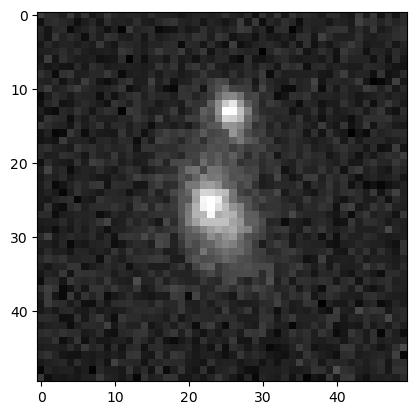

In [103]:
import matplotlib.pyplot as plt
plt.imshow(image_cutout, cmap='grey')

Isn't it pretty? The last thing we need is a weightmap — a measure of the estimated error in the image due to certain steps taken when the image is processed. This is important so that `statmorph` can take in mind error when calculating morphological parameters. To get the weightmap, we pull the variance from the visit_image, and calculate its inverse to get the weightmap array.

In [104]:
variance = visit_image.getVariance().array
variance_array = get_cutout(variance,int(xy[0]),int(xy[1]))
variance_np = variance_array.astype(np.float32)  # Now a true NumPy array
#Compute weight map
eps = 1e-10
weightmap = 1.0 / (variance_np + eps)  

Now, we have all that we need to run `statmorph` on our target galaxy! Lets import the package and run the `statmorph.source_morphology()` function, passing the arguments `image_cutout`, `mask_cutout`, and `weightmap`. The Rubin Science Platform doesn't come with `statmorph` installed natively, so if you haven't yet, open a new terminal window within the RSP and just run `$pip install statmorph`

In [93]:
import statmorph
demo = statmorph.source_morphology(image_cutout,mask_cutout,weightmap=weightmap)

To view the results, `statmorph` has a built in command called make_figure. Let's use it to generate a nice-looking figure for our galaxy.

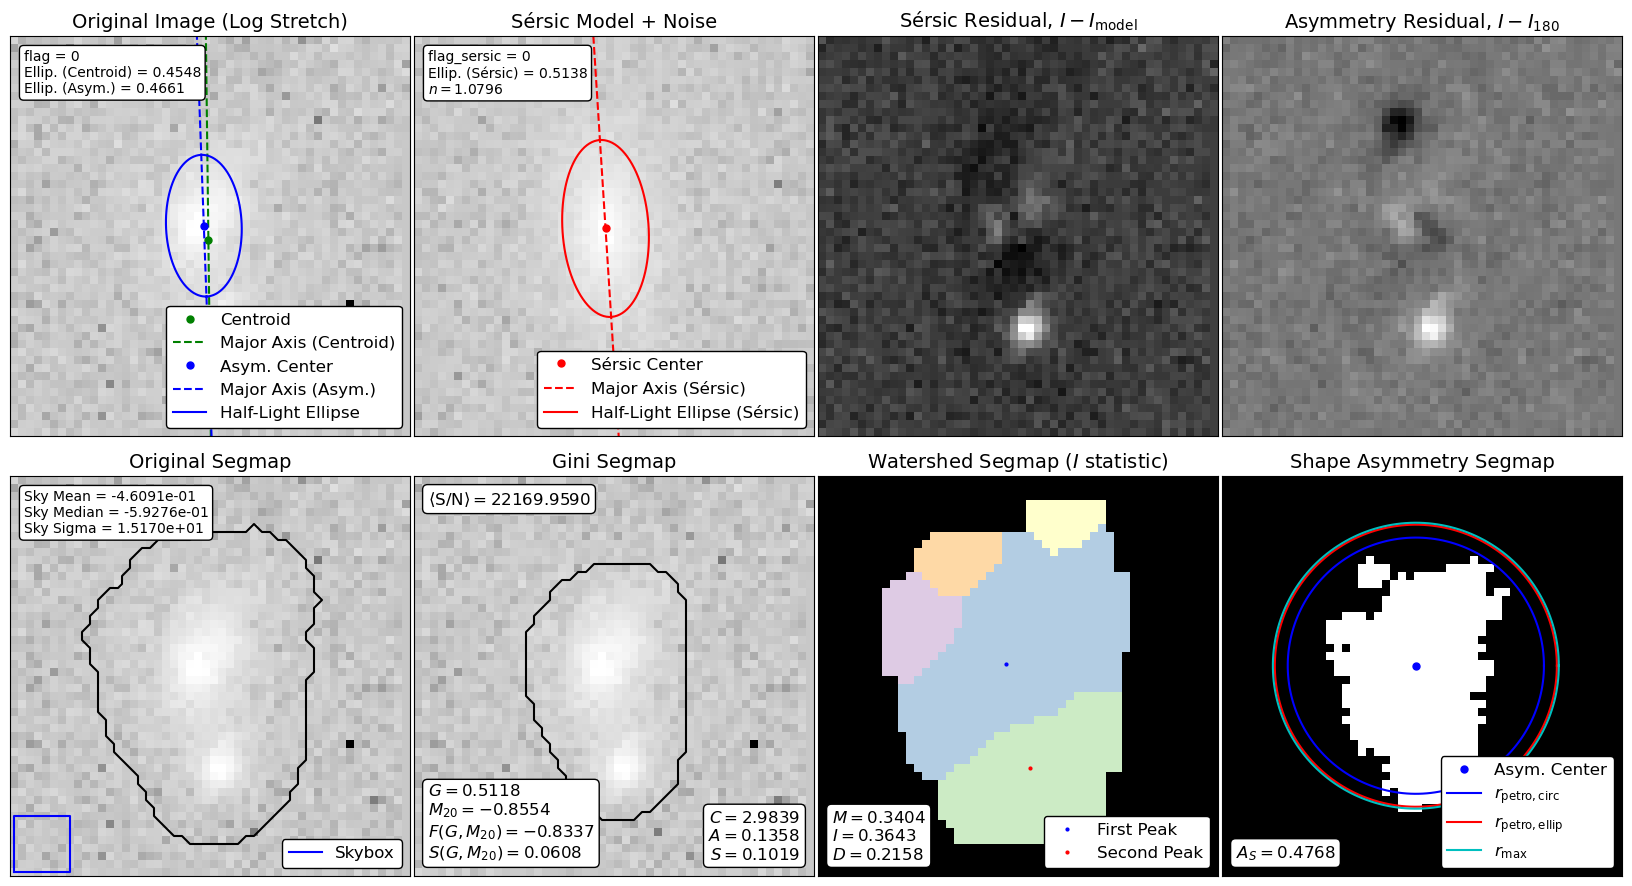

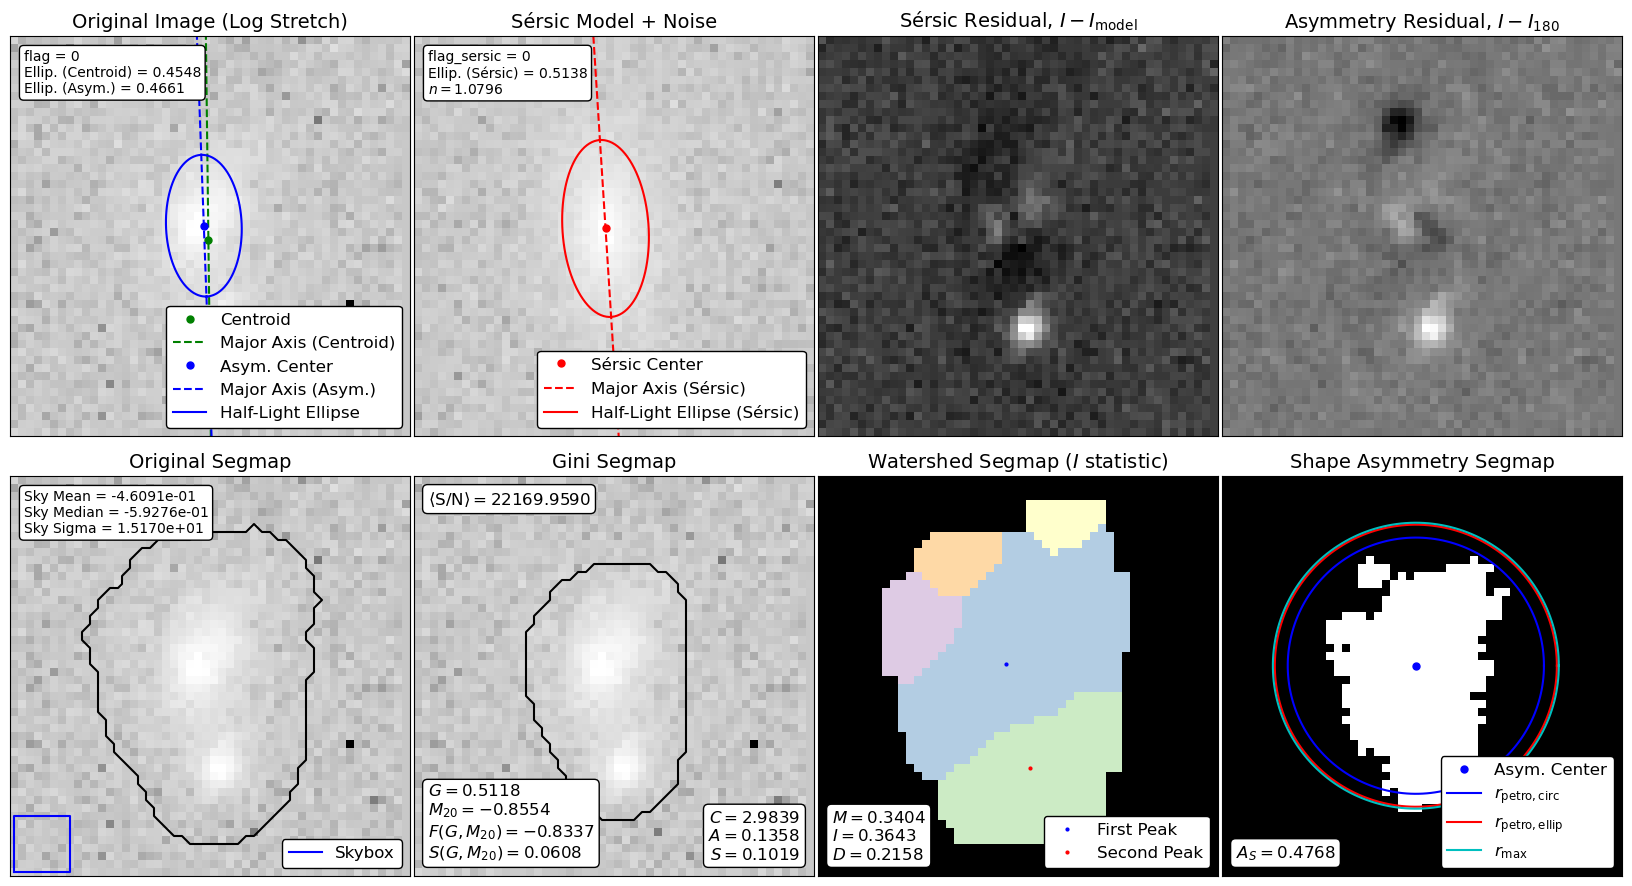

In [94]:
from statmorph.utils.image_diagnostics import make_figure
make_figure(demo[0])